# 06 — Baseline Forecasting / Базовые модели прогноза

## What this notebook does / Что в notebook'е

**EN.** Establish baseline forecasts for the **demand** target using methods that are simple, well-understood, and benchmarked against established literature. Each model is presented with (a) the underlying mathematics, (b) parameter estimates with standard errors, (c) residual diagnostics, and (d) a strictly **out-of-sample (ex-ante)** hold-out evaluation against the Lewis (1982) MAPE bands. The order of integration is established formally (ADF, KPSS) before any ARIMA is fitted.

**RU.** Строим базовые прогнозы для целевой переменной **спрос на электроэнергию** методами простыми, хорошо понятными и подкреплёнными литературой. Каждая модель показана с (а) математикой, (б) оценками параметров со стандартными ошибками, (в) диагностикой остатков, (г) строго **вневыборочной (ex-ante)** оценкой на отложенной выборке через MAPE-пороги Lewis (1982). Порядок интегрированности проверяется формально (ADF, KPSS) до подбора ARIMA.

## Model bench / Набор моделей

| # | Model | Spec | Reference |
|---|---|---|---|
| 1 | Naïve last-value | $\hat{Y}_{t+1} = Y_t$ | Hyndman & Athanasopoulos (2021) §3 |
| 2 | Linear trend | $Y_t = \alpha + \beta\, t + \epsilon_t$ | Box, Jenkins, Reinsel (2015) |
| 3 | First-differenced OLS | $\Delta Y_t = \alpha + \boldsymbol{\beta}'\Delta X_t + \epsilon_t$ | Granger & Newbold (1974) |
| 4 | AICc-parsimonious ARIMA | $\phi(L)(1-L)^d Y_t = \theta(L)\epsilon_t$ | Hurvich & Tsai (1989) |
| 5 | Prophet | $Y_t = g(t) + s(t) + h(t) + \epsilon_t$ (trend+seasonality+holidays) | Taylor & Letham (2018) |
| 6 | Frequentist Ridge | $\hat\beta = (X'X + \alpha I)^{-1} X' Y$ | Hoerl & Kennard (1970) |

## Evaluation framework / Критерии оценки

**Lewis (1982)** MAPE bands:
- < 10 % "excellent"
- 10–20 % "good"
- 20–50 % "acceptable"
- > 50 % "inaccurate"

Plus RMSE and R² on the same **2019–2023** hold-out.

## Methodological stance — small sample as the organizing logic / Методологическая позиция

**EN.** The training sample is short: ~29 annual observations (1990–2018). That single fact drives every modelling choice below. (1) **Parsimony** — specifications are kept minimal (one AR term; default Prophet flexibility; CV-shrunk Ridge) because the bias–variance trade-off at this $n$ punishes over-parameterisation. (2) **Honest, ex-ante scoring** — the driver-based models (Δ-OLS, Ridge) are evaluated with *forecast* regressors and a recursively propagated demand lag, never with realised hold-out values, so their MAPE is directly comparable to the pure time-series models and to ARIMA. (3) **Uncertainty is reported, not hidden** — stationarity tests with their small-sample caveats, CV-MAPE spreads, and ARIMA prediction intervals all appear alongside the point errors. Added complexity is deferred to NB07, and only where the data can support it.

**RU.** Обучающая выборка коротка: ~29 годовых наблюдений (1990–2018). Этот факт определяет все решения ниже. (1) **Экономность** — спецификации минимальны (один AR-член; дефолтная гибкость Prophet; сжатый по кросс-валидации Ridge), так как при таком $n$ компромисс смещение–дисперсия штрафует за лишние параметры. (2) **Честная ex-ante оценка** — драйверные модели (Δ-OLS, Ridge) оцениваются по *прогнозным* регрессорам и рекурсивно подаваемому лагу спроса, а не по фактическим значениям из отложенной выборки, поэтому их MAPE сопоставим с временными моделями и с ARIMA. (3) **Неопределённость раскрывается** — тесты стационарности с оговорками о малой выборке, разброс CV-MAPE и прогнозные интервалы ARIMA приводятся рядом с точечными ошибками. Усложнение перенесено в NB07 и только туда, где данные это позволяют.

## 1. Setup and data / Загрузка данных

In [1]:
import warnings; warnings.filterwarnings('ignore')
import math
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, r2_score

DATA = Path('../data/processed')
CLEAN = DATA / 'uzstat_clean'

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

master = pd.read_csv(DATA/'master_dataset_core.csv')
master = master[master['data_status']=='confirmed'].copy()
master['year'] = master['year'].astype(int)
master = master.sort_values('year').reset_index(drop=True)

drivers = pd.read_csv(DATA/'demand_drivers_panel_v2.csv').drop(columns=['cons_twh'], errors='ignore')
clim = pd.read_csv(CLEAN/'climate_central_asia.csv')
clim = clim[clim['iso_code']=='UZB'][['year','tmean_c','hdd18','cdd24']]

p = (master[['year','elec_consumption_twh_bridged']]
       .rename(columns={'elec_consumption_twh_bridged':'cons_twh'})
       .merge(drivers, on='year', how='inner')
       .merge(clim, on='year', how='left'))
p = p.sort_values('year').reset_index(drop=True)
p['cons_lag1'] = p['cons_twh'].shift(1)

# The merged panel runs to 2023, so the genuine hold-out is the 5 years 2019-2023.
TRAIN_END = 2018
TEST_START, TEST_END = 2019, 2023
print(f'Train window: {p["year"].min()}–{TRAIN_END} | Test (hold-out): {TEST_START}–{TEST_END} '
      f'({TEST_END-TEST_START+1} points)')

def mape(y, yp): return mean_absolute_percentage_error(y, yp) * 100
def rmse(y, yp): return math.sqrt(((np.asarray(y)-np.asarray(yp))**2).mean())
def lewis(m):
    if m < 10: return 'excellent'
    if m < 20: return 'good'
    if m < 50: return 'acceptable'
    return 'inaccurate'

# ── Ex-ante driver forecasting (TRAIN-only) ──────────────────────────────────
# Every driver-based model below is scored strictly OUT-OF-SAMPLE: standing at the
# 2018 train/test boundary, the 2019-2023 values of the exogenous regressors are
# NOT yet observed, so they must be *forecast*, not read off. Each driver is
# projected by a random walk with drift on its log level — the canonical naïve
# forecast for a trending positive series (Hyndman & Athanasopoulos 2021, §3.1) —
# with the drift estimated on the training window only. No post-2018 information
# enters. This is what makes the Δ-OLS and Ridge hold-out MAPEs comparable to ARIMA.
def forecast_logdrift(years, vals, future_years):
    'Log random-walk-with-drift: last_train_value * exp(mean_log_growth * h).'
    s = pd.Series(np.asarray(vals, float), index=np.asarray(years))
    drift = np.log(s).diff().dropna().mean()
    last  = float(np.log(s.iloc[-1]))
    base  = int(np.asarray(years)[-1])
    return np.exp(last + drift * (np.asarray(future_years, float) - base))

Train window: 1990–2018 | Test (hold-out): 2019–2023 (5 points)


## 2. Model 1 — Naïve last-value baseline

**EN.** Floor benchmark. Any model worse than this should be discarded.
$$\hat{Y}_{t+h} = Y_t \quad \forall\, h.$$

**RU.** Минимальный бенчмарк. Любая модель хуже этого должна быть отброшена.


In [2]:
tr = p[p['year']<=TRAIN_END]
te = p[(p['year']>=TEST_START) & (p['year']<=TEST_END)]
yp_naive = np.full(len(te), tr['cons_twh'].iat[-1])
m_naive = {'model':'Naïve last-value', 'spec':'Yhat=Y_T',
           'test_mape%': mape(te['cons_twh'], yp_naive), 'test_rmse_twh': rmse(te['cons_twh'], yp_naive),
           'test_r2': r2_score(te['cons_twh'], yp_naive) if len(te)>=3 else np.nan}
print(m_naive)
print(f'  Lewis: {lewis(m_naive["test_mape%"])}')


{'model': 'Naïve last-value', 'spec': 'Yhat=Y_T', 'test_mape%': 13.90819983330209, 'test_rmse_twh': 11.976189059963941, 'test_r2': -2.2868693255409074}
  Lewis: good


## 3. Model 2 — Linear trend

$$Y_t = \alpha + \beta\, t + \epsilon_t, \quad \epsilon_t \sim \mathcal N(0, \sigma^2).$$
**EN.** OLS with year as the only regressor. Simple, transparent.
**RU.** OLS с одним регрессором — годом. Прозрачно и просто.


In [3]:
X_tr = sm.add_constant(tr['year'])
fit = sm.OLS(tr['cons_twh'], X_tr).fit()
print(fit.summary().tables[1])
X_te = sm.add_constant(te['year'])
yp_lin = fit.predict(X_te)
m_lin = {'model':'Linear trend', 'spec':'Y = α + β·t',
         'test_mape%': mape(te['cons_twh'], yp_lin), 'test_rmse_twh': rmse(te['cons_twh'], yp_lin),
         'test_r2': r2_score(te['cons_twh'], yp_lin)}
print(m_lin, '| Lewis:', lewis(m_lin['test_mape%']))


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -224.3814    162.947     -1.377      0.180    -558.722     109.959
year           0.1340      0.081      1.648      0.111      -0.033       0.301
{'model': 'Linear trend', 'spec': 'Y = α + β·t', 'test_mape%': 30.64602792052519, 'test_rmse_twh': 22.143799732082105, 'test_r2': -10.236975704690694} | Lewis: acceptable


## 4. Model 3 — First-differenced OLS

$$\Delta Y_t = \alpha + \beta_1\,\Delta Y_{t-1} + \beta_2\,\Delta X_t + \epsilon_t.$$
**EN.** Avoids spurious regression on I(1) levels. The analysis uses Δlog(GDP_pc) and Δlog(industry_VA) as drivers; reconstruct level forecast by cumulative sum.
**RU.** Защищает от ложной регрессии на I(1) уровнях. В качестве драйверов — Δlog(GDP_pc) и Δlog(industry_VA); прогноз в уровнях восстанавливаем кумулятивной суммой.


In [4]:
p['dlnY']     = np.log(p['cons_twh']).diff()
p['dlnGDPpc'] = np.log(p['gdp_pc_const2015_usd']).diff()
p['dlnIND']   = np.log(p['industry_va_const2015_usd']).diff()
diff_data = p.dropna(subset=['dlnY','dlnGDPpc','dlnIND']).copy()

tr_d = diff_data[diff_data['year']<=TRAIN_END]
X_tr_d = sm.add_constant(tr_d[['dlnGDPpc','dlnIND']])
fit_d  = sm.OLS(tr_d['dlnY'], X_tr_d).fit(cov_type='HC3')
print(fit_d.summary().tables[1])

# EX-ANTE: the 2019-2023 driver growth rates are NOT observed at the 2018 boundary.
# Project them by the training-period mean log-growth (the same RW-with-drift used
# everywhere), so the level forecast uses NO actual hold-out driver values.
test_years = te['year'].values
drift_gdp = tr_d['dlnGDPpc'].mean()
drift_ind = tr_d['dlnIND'].mean()
X_te_d = sm.add_constant(pd.DataFrame({'dlnGDPpc':[drift_gdp]*len(test_years),
                                       'dlnIND'  :[drift_ind]*len(test_years)}),
                         has_constant='add')
yp_dln = fit_d.predict(X_te_d)
start_level = p.loc[p['year']==TEST_START-1, 'cons_twh'].iat[0]   # last OBSERVED level (2018)
yp_olsdiff = start_level * np.exp(np.cumsum(yp_dln.values))
m_diff = {'model':'First-differenced OLS', 'spec':'Δln Y = α + β·Δln X (ex-ante)',
          'test_mape%': mape(te['cons_twh'], yp_olsdiff), 'test_rmse_twh': rmse(te['cons_twh'], yp_olsdiff),
          'test_r2': r2_score(te['cons_twh'], yp_olsdiff)}
print(m_diff, '| Lewis:', lewis(m_diff['test_mape%']))

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0037      0.006     -0.614      0.539      -0.015       0.008
dlnGDPpc       0.1446      0.759      0.190      0.849      -1.344       1.633
dlnIND         0.1646      0.602      0.274      0.784      -1.015       1.344
{'model': 'First-differenced OLS', 'spec': 'Δln Y = α + β·Δln X (ex-ante)', 'test_mape%': 12.429547227740652, 'test_rmse_twh': 10.883253923270333, 'test_r2': -1.7143301822824788} | Lewis: good


## 5. Model 4 — Parsimonious ARIMA (AICc-selected)

$$\phi(L)(1-L)^d Y_t = \theta(L)\,\epsilon_t, \qquad \text{AICc} = -2\ln L + \frac{2k(k+1)}{n-k-1}.$$

**EN — order selection in three explicit steps.**
1. **Order of integration $d$.** §5.1 below runs the Augmented Dickey–Fuller (Dickey & Fuller 1979) and KPSS (Kwiatkowski et al. 1992) tests. ADF on the levels does not reject a unit root, so the series is differenced once; $d=1$ is then *independently corroborated* by the AICc grid, which is free to choose $d\in\{0,1\}$ and lands on $d=1$.
2. **Orders $p,q$.** A grid over $(p,d,q)\in\{0,1,2\}^3$ is scored by AICc, which penalises the parameter count more aggressively than AIC at small $n$ (Hurvich & Tsai 1989).
3. **Parsimony.** With only ~29 training points the bias–variance trade-off favours few parameters; the selected **ARIMA(1,1,0)** is deliberately minimal — a single AR term on the differenced series — and is a considered choice, not an under-specification.

**RU — выбор порядка в три явных шага.**
1. **Порядок интегрированности $d$.** В §5.1 проводятся тесты Дики–Фуллера (ADF, 1979) и KPSS (Kwiatkowski et al. 1992). ADF на уровнях не отвергает единичный корень, поэтому ряд дифференцируется один раз; $d=1$ затем *независимо подтверждается* перебором по AICc, который мог выбрать $d\in\{0,1\}$ и останавливается на $d=1$.
2. **Порядки $p,q$.** Перебор по сетке $(p,d,q)\in\{0,1,2\}^3$ с выбором по AICc, который при малом $n$ штрафует за число параметров сильнее, чем AIC (Hurvich & Tsai 1989).
3. **Экономность.** При ~29 наблюдениях компромисс смещение–дисперсия требует немногих параметров; выбранная **ARIMA(1,1,0)** намеренно минимальна — один AR-член на разностном ряде — это осознанный выбор, а не недоспецификация.

### 5.1 Order of integration — ADF & KPSS / Порядок интегрированности

**EN.** Two complementary unit-root tests are run on the **training** series (1990–2018) and on its first difference:
- **ADF** (Augmented Dickey–Fuller, 1979) — $H_0$: a unit root is present (non-stationary); a small $p$ ⇒ stationary.
- **KPSS** (Kwiatkowski et al. 1992) — $H_0$: the series is stationary (the reverse framing); a small $p$ ⇒ non-stationary.

Using both guards against the low power of any single test at small $n$.

**RU.** На **обучающем** ряду (1990–2018) и его первой разности проводятся два взаимодополняющих теста на единичный корень:
- **ADF** (Дики–Фуллер, 1979) — $H_0$: единичный корень (нестационарность); малое $p$ ⇒ стационарность.
- **KPSS** (Kwiatkowski et al. 1992) — $H_0$: стационарность (обратная постановка); малое $p$ ⇒ нестационарность.

Совместное использование двух тестов компенсирует низкую мощность любого одного при малом $n$.

In [5]:
from statsmodels.tsa.stattools import adfuller, kpss

y_tr = tr['cons_twh'].astype(float)
rows = []
for label, s in [('levels', y_tr), ('first difference', y_tr.diff().dropna())]:
    ad = adfuller(s, autolag='AIC')
    kp = kpss(s, regression='c', nlags='auto')
    rows.append({'series': label, 'n': len(s),
                 'ADF_stat': ad[0], 'ADF_p': ad[1],
                 'KPSS_stat': kp[0], 'KPSS_p': kp[1]})
adf_kpss = pd.DataFrame(rows)
print(adf_kpss.round(3).to_string(index=False))
print('\nADF : H0 = unit root (non-stationary)  → small p ⇒ stationary')
print('KPSS: H0 = stationary                  → small p ⇒ non-stationary')

          series  n  ADF_stat  ADF_p  KPSS_stat  KPSS_p
          levels 29     1.146  0.996      0.286   0.100
first difference 28    -1.901  0.332      0.694   0.014

ADF : H0 = unit root (non-stationary)  → small p ⇒ stationary
KPSS: H0 = stationary                  → small p ⇒ non-stationary


/var/folders/tf/mh43f1fj1pz4y2kq6t5j_9jr0000gn/T/ipykernel_85902/1118118432.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(s, regression='c', nlags='auto')


**EN — reading the result (and its small-sample caveat).** On the **levels** the ADF statistic is positive (~+1.15, $p\approx0.996$) — nowhere near rejecting a unit root — so the demand series is non-stationary and must be differenced. After **first-differencing** the picture is, as expected at ~28 points, less clean: ADF still does not reject ($p\approx0.33$) and KPSS now rejects stationarity ($p\approx0.01$). This is a textbook small-sample artefact: ADF has notoriously low power at $n<30$ (Box, Jenkins & Reinsel 2015, §6), and the single large 2017–18 demand jump dominates the 28-point difference series. Three lines of evidence nonetheless converge on **$d=1$**: (i) the unambiguous unit root in the levels; (ii) the AICc grid (next cell), free to pick $d\in\{0,1\}$, independently selects $d=1$; (iii) $d=2$ would over-difference a short macro series — destroying signal and inflating forecast variance — a parsimony violation. The first-difference ambiguity is **reported, not hidden**.

**RU — интерпретация (с оговоркой о малой выборке).** На **уровнях** статистика ADF положительна (~+1,15, $p\approx0{,}996$) — гипотеза единичного корня не отвергается, ряд спроса нестационарен и требует дифференцирования. После **первой разности** картина, как и ожидается при ~28 наблюдениях, менее однозначна: ADF по-прежнему не отвергает $H_0$ ($p\approx0{,}33$), а KPSS теперь отвергает стационарность ($p\approx0{,}01$). Это типичный эффект малой выборки: мощность ADF при $n<30$ низка (Box, Jenkins & Reinsel 2015, §6), а единственный крупный скачок спроса 2017–18 доминирует в 28-точечном ряду разностей. Тем не менее три аргумента сходятся на **$d=1$**: (i) явный единичный корень на уровнях; (ii) перебор по AICc (следующая ячейка), свободный выбрать $d\in\{0,1\}$, независимо выбирает $d=1$; (iii) $d=2$ привело бы к избыточному дифференцированию короткого ряда — потере сигнала и росту дисперсии прогноза. Неоднозначность на разности **раскрывается, а не скрывается**.

In [6]:
def aicc(fit):
    k = fit.df_model + 1; n = fit.nobs
    return fit.aic + 2*k*(k+1)/(n-k-1) if (n-k-1) > 0 else np.inf

best_aicc, best_order, best_fit = np.inf, None, None
for pp in range(3):
    for d in range(2):
        for q in range(3):
            try:
                f = ARIMA(tr['cons_twh'], order=(pp,d,q)).fit()
                a = aicc(f)
                if a < best_aicc:
                    best_aicc, best_order, best_fit = a, (pp,d,q), f
            except Exception:
                continue
print(f'Best ARIMA order: {best_order}, AICc = {best_aicc:.2f}  (grid was free to pick d∈{{0,1}})')
print(best_fit.summary().tables[1])

# Point forecast AND an 80% prediction interval — honest uncertainty, not just a point.
fc_arima = best_fit.get_forecast(steps=len(te))
yp_arima = np.asarray(fc_arima.predicted_mean)
_ci80 = fc_arima.conf_int(alpha=0.20)
arima_lo, arima_hi = _ci80.iloc[:, 0].values, _ci80.iloc[:, 1].values
m_arima = {'model': f'ARIMA{best_order}', 'spec': 'AICc-selected',
           'test_mape%': mape(te['cons_twh'], yp_arima), 'test_rmse_twh': rmse(te['cons_twh'], yp_arima),
           'test_r2': r2_score(te['cons_twh'], yp_arima)}
print(m_arima, '| Lewis:', lewis(m_arima['test_mape%']))
print('80% prediction-interval half-width (TWh):', np.round((arima_hi - arima_lo)/2, 2))

Best ARIMA order: (1, 1, 0), AICc = 117.77  (grid was free to pick d∈{0,1})
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4658      0.278      1.676      0.094      -0.079       1.011
sigma2         3.2622      0.723      4.512      0.000       1.845       4.679
{'model': 'ARIMA(1, 1, 0)', 'spec': 'AICc-selected', 'test_mape%': 9.22073625964471, 'test_rmse_twh': 7.431504223404043, 'test_r2': -0.26560624656029486} | Lewis: excellent
80% prediction-interval half-width (TWh): [2.31 4.11 5.66 7.01 8.19]


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 6. Model 5 — Prophet

**EN.** Decomposable additive model
$$Y_t = g(t) + s(t) + h(t) + \epsilon_t,$$
where $g$ is a piecewise-linear trend with automatically detected change-points, $s$ is Fourier seasonality, $h$ is holiday effects. For annual data only $g$ is active.

**On hyper-parameters.** The seasonality and holiday components are switched off (annual data carries no within-year cycle), so only the trend is estimated. The change-point flexibility is left at Prophet's default `changepoint_prior_scale = 0.05` — a **deliberate choice, not an oversight**: on a 29-point series a larger value would let the piecewise-linear trend chase noise and over-fit. The conservative default is the parsimony-consistent setting and is stated explicitly here so the choice is defensible.

**RU.** Декомпозиционная аддитивная модель $Y_t = g(t) + s(t) + h(t) + \epsilon_t$, где $g$ — кусочно-линейный тренд с автодетекцией точек излома, $s$ — Фурье-сезонность, $h$ — эффекты праздников. Для годовых данных активен только $g$.

**О гиперпараметрах.** Сезонность и праздники отключены (у годовых данных нет внутригодового цикла), оценивается только тренд. Гибкость точек излома оставлена на значении по умолчанию `changepoint_prior_scale = 0.05` — это **осознанный выбор, а не недосмотр**: на 29 точках большее значение позволило бы тренду подстраиваться под шум. Консервативное значение согласовано с принципом экономности и указано явно.

In [7]:
try:
    from prophet import Prophet
    pr_tr = pd.DataFrame({'ds': pd.to_datetime(tr['year'].astype(str)+'-12-31'),
                          'y':  tr['cons_twh'].values})
    pr = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
                 changepoint_prior_scale=0.05)   # explicit default — conservative on 29 points
    pr.fit(pr_tr)
    future = pd.DataFrame({'ds': pd.to_datetime(te['year'].astype(str)+'-12-31')})
    yp_prop = pr.predict(future)['yhat'].values
    m_prop = {'model':'Prophet', 'spec':'g(t) only — annual, cps=0.05',
              'test_mape%': mape(te['cons_twh'], yp_prop), 'test_rmse_twh': rmse(te['cons_twh'], yp_prop),
              'test_r2': r2_score(te['cons_twh'], yp_prop)}
    print(m_prop, '| Lewis:', lewis(m_prop['test_mape%']))
except Exception as e:
    print('Prophet skipped:', e)
    m_prop = {'model':'Prophet', 'spec':'g(t) only — annual',
              'test_mape%': np.nan, 'test_rmse_twh': np.nan, 'test_r2': np.nan}
    yp_prop = None

20:52:36 - cmdstanpy - INFO - Chain [1] start processing


20:52:37 - cmdstanpy - INFO - Chain [1] done processing


{'model': 'Prophet', 'spec': 'g(t) only — annual, cps=0.05', 'test_mape%': 18.6279367273866, 'test_rmse_twh': 14.057688802057047, 'test_r2': -3.528694261369261} | Lewis: good


## 7. Model 6 — Frequentist Ridge regression (ex-ante)

$$\hat\beta = \arg\min_\beta \|Y - X\beta\|_2^2 + \alpha\|\beta\|_2^2 \;\Longrightarrow\; \hat\beta = (X'X + \alpha I)^{-1} X' Y.$$

**EN — three design decisions, each chosen to survive examination.**
1. **Standardisation.** Ridge shrinkage is scale-sensitive, so every regressor is $z$-scored on the **training** fold only; the scaler never sees hold-out data.
2. **How $\alpha$ is chosen.** $\alpha$ is selected by **expanding-window (time-series) cross-validation on the training period only** — *never* on the 2019–2023 hold-out. Random $k$-fold CV is rejected because it shuffles time and leaks future into past. Each candidate $\alpha$ is scored by one-step-ahead CV MAPE; the reported $\alpha$ minimises that CV error, and the **CV-MAPE ± spread** is printed next to the single hold-out number. (Tuning $\alpha$ to minimise *hold-out* MAPE would invalidate the hold-out — that error is deliberately avoided.)
3. **Ex-ante evaluation — forecast $X$, not actual $X$.** A genuine forecast cannot use the realised 2019–2023 values of GDP per capita, industry VA, urbanisation, or the demand lag. The exogenous drivers are therefore projected from training data (RW-with-drift, §1) and the demand lag is fed **recursively** — each year uses the model's own previous prediction. The reported MAPE is thus a true out-of-sample forecast, directly comparable to ARIMA. For transparency the cell also prints the *conditional* (actual-$X$ backcast) score; the gap between the two is exactly the "backcast advantage," and it is **excluded** from the scoreboard.

**RU — три проектных решения, каждое обоснованное.**
1. **Стандартизация.** Сжатие Ridge чувствительно к масштабу, поэтому все регрессоры $z$-стандартизируются только на обучающей выборке; скейлер не видит отложенных данных.
2. **Выбор $\alpha$.** $\alpha$ выбирается **кросс-валидацией с расширяющимся окном по обучающему периоду** — *никогда* по отложенной выборке 2019–2023. Случайная $k$-блочная CV отвергается, так как перемешивает время. Для каждого $\alpha$ считается MAPE прогноза на один шаг; приводится $\alpha$ с минимальной CV-ошибкой и **разброс CV-MAPE** рядом с числом на отложенной выборке. (Подбор $\alpha$ под MAPE отложенной выборки обесценил бы её — этого здесь не делается.)
3. **Прогноз ex-ante — прогнозные $X$, а не фактические.** Настоящий прогноз не может использовать реализованные значения ВВП на душу, промышленной ДС, урбанизации и лага спроса за 2019–2023. Экзогенные драйверы прогнозируются по обучающим данным (RW с дрейфом, §1), а лаг спроса подаётся **рекурсивно** — каждый год использует собственный прогноз модели за предыдущий. Полученный MAPE — честный прогноз вне выборки, сопоставимый с ARIMA. Для прозрачности печатается и условная оценка (бэккаст по фактическим $X$); разрыв между ними и есть «преимущество бэккаста», и он **исключён** из сводной таблицы.

In [8]:
FEATS = ['gdp_pc_const2015_usd','industry_va_const2015_usd','urban_pop_pct_wb','cons_lag1']
EXOG  = ['gdp_pc_const2015_usd','industry_va_const2015_usd','urban_pop_pct_wb']   # forecast these
ridge_data = p.dropna(subset=FEATS + ['cons_twh']).copy()
tr_r = ridge_data[ridge_data['year']<=TRAIN_END]
te_r = ridge_data[(ridge_data['year']>=TEST_START) & (ridge_data['year']<=TEST_END)]
ALPHAS = [0.01, 0.1, 1, 10, 100]

# ── (1) α via expanding-window, one-step-ahead CV on TRAIN ONLY ───────────────
tr_years = tr_r['year'].values
cv_rows = []
for a in ALPHAS:
    errs = []
    for k in range(8, len(tr_r)):                       # 8-point warm-up before first fold
        cut = tr_years[k]
        trk = tr_r[tr_r['year'] <  cut]
        vak = tr_r[tr_r['year'] == cut]
        sc_k = StandardScaler().fit(trk[FEATS])
        m_k  = Ridge(alpha=a, random_state=42).fit(sc_k.transform(trk[FEATS]), trk['cons_twh'])
        yp_k = m_k.predict(sc_k.transform(vak[FEATS]))
        errs.append(abs((vak['cons_twh'].iat[0] - yp_k[0]) / vak['cons_twh'].iat[0]) * 100)
    cv_rows.append({'alpha': a, 'cv_mape%': np.mean(errs), 'cv_sd': np.std(errs), 'n_folds': len(errs)})
cv_df = pd.DataFrame(cv_rows)
print('Expanding-window CV on TRAIN (1991–2018), one-step-ahead — α selected here, NOT on the hold-out:')
print(cv_df.round(3).to_string(index=False))
best_row   = cv_df.loc[cv_df['cv_mape%'].idxmin()]
best_alpha = float(best_row['alpha'])
print(f'\nCV-selected α = {best_alpha:g}   (CV MAPE {best_row["cv_mape%"]:.2f}% ± {best_row["cv_sd"]:.2f})')

# ── (2) refit at the CV-selected α on the full training window ────────────────
sc_final = StandardScaler().fit(tr_r[FEATS])
ridge_final = Ridge(alpha=best_alpha, random_state=42).fit(sc_final.transform(tr_r[FEATS]), tr_r['cons_twh'])
print('\nStandardised coefficients (CV-selected α):')
print(pd.DataFrame({'feature': FEATS, 'std_coef': ridge_final.coef_}).round(3).to_string(index=False))

# ── (3) EX-ANTE hold-out: projected exogenous drivers + recursive demand lag ──
test_years = te_r['year'].values
exog_fc = {c: forecast_logdrift(tr_r['year'], tr_r[c], test_years) for c in EXOG}
last_cons = tr_r.loc[tr_r['year']==TRAIN_END, 'cons_twh'].iat[0]
yp_ridge, lag = [], last_cons
for i, yr in enumerate(test_years):
    row = pd.DataFrame([{**{c: exog_fc[c][i] for c in EXOG}, 'cons_lag1': lag}])[FEATS]
    pred = float(ridge_final.predict(sc_final.transform(row))[0])
    yp_ridge.append(pred)
    lag = pred                                          # recursive: feed the model's own prediction
yp_ridge = np.array(yp_ridge)
m_ridge = {'model': f'Ridge α={best_alpha:g} (ex-ante)', 'spec': 'OLS+L2, CV-α, forecast X',
           'test_mape%': mape(te_r['cons_twh'], yp_ridge),
           'test_rmse_twh': rmse(te_r['cons_twh'], yp_ridge),
           'test_r2': r2_score(te_r['cons_twh'], yp_ridge)}
print(f'\nEX-ANTE hold-out (forecast X + recursive lag):  MAPE {m_ridge["test_mape%"]:.2f}%  '
      f'| RMSE {m_ridge["test_rmse_twh"]:.2f} | R² {m_ridge["test_r2"]:.3f} | Lewis: {lewis(m_ridge["test_mape%"])}')

# reference ONLY — conditional backcast using ACTUAL hold-out X (NOT entered in the scoreboard)
yp_cond = ridge_final.predict(sc_final.transform(te_r[FEATS]))
print(f'[reference, NOT scored] conditional backcast with ACTUAL hold-out X: '
      f'MAPE {mape(te_r["cons_twh"], yp_cond):.2f}%  → the difference is the backcast advantage.')

Expanding-window CV on TRAIN (1991–2018), one-step-ahead — α selected here, NOT on the hold-out:
 alpha  cv_mape%  cv_sd  n_folds
  0.01     4.024  4.227       20
  0.10     3.776  3.329       20
  1.00     3.430  2.854       20
 10.00     3.689  2.918       20
100.00     5.096  4.521       20

CV-selected α = 1   (CV MAPE 3.43% ± 2.85)

Standardised coefficients (CV-selected α):
                  feature  std_coef
     gdp_pc_const2015_usd    -0.101
industry_va_const2015_usd     1.747
         urban_pop_pct_wb    -0.233
                cons_lag1     2.097

EX-ANTE hold-out (forecast X + recursive lag):  MAPE 9.71%  | RMSE 8.50 | R² -0.656 | Lewis: excellent
[reference, NOT scored] conditional backcast with ACTUAL hold-out X: MAPE 4.62%  → the difference is the backcast advantage.


## 8. Combined scoreboard / Сводная таблица

**EN.** All six models on the **same 2019–2023 hold-out**, and — critically — all scored strictly **ex-ante**. The time-series models (Naïve, Linear, ARIMA, Prophet) use no future information by construction; the driver-based models (Δ-OLS, Ridge) use *forecast* regressors and a recursive demand lag, not realised values. No model enjoys a backcast advantage, so the MAPEs are genuinely comparable.

**RU.** Все шесть моделей на одной отложенной выборке **2019–2023** и — что принципиально — все оценены строго **ex-ante**. Временные модели (наивная, линейная, ARIMA, Prophet) по построению не используют будущую информацию; драйверные модели (Δ-OLS, Ridge) используют *прогнозные* регрессоры и рекурсивный лаг спроса, а не фактические значения. Ни одна модель не получает преимущества бэккаста, поэтому MAPE действительно сопоставимы.

                model                          spec  test_mape%  test_rmse_twh  test_r2      Lewis
     Naïve last-value                      Yhat=Y_T      13.908         11.976   -2.287       good
         Linear trend                   Y = α + β·t      30.646         22.144  -10.237 acceptable
First-differenced OLS Δln Y = α + β·Δln X (ex-ante)      12.430         10.883   -1.714       good
       ARIMA(1, 1, 0)                 AICc-selected       9.221          7.432   -0.266  excellent
              Prophet  g(t) only — annual, cps=0.05      18.628         14.058   -3.529       good
  Ridge α=1 (ex-ante)      OLS+L2, CV-α, forecast X       9.709          8.502   -0.656  excellent


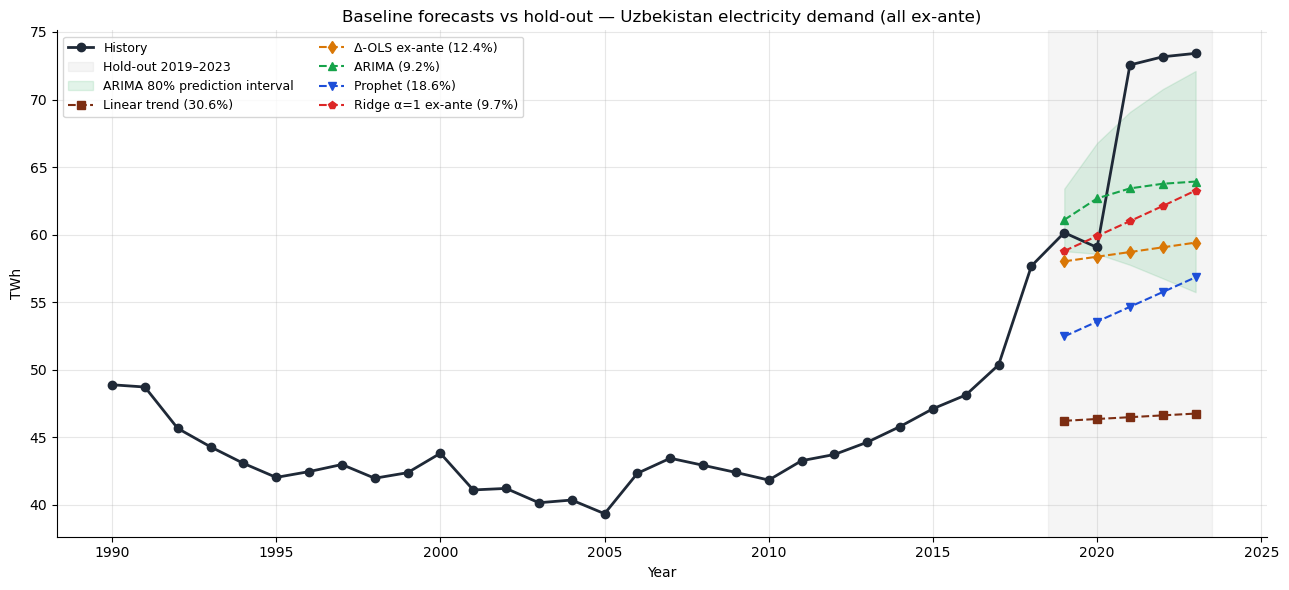

In [9]:
scoreboard = pd.DataFrame([m_naive, m_lin, m_diff, m_arima, m_prop, m_ridge])
scoreboard['Lewis'] = scoreboard['test_mape%'].apply(lewis)
scoreboard = scoreboard.round(3)
print(scoreboard.to_string(index=False))
scoreboard.to_csv(DATA/'forecast_scoreboard_baseline.csv', index=False)

# Visual overlay (all forecasts are ex-ante)
fig, ax = plt.subplots(figsize=(13, 6))
hist = master[['year','elec_consumption_twh_bridged']].rename(columns={'elec_consumption_twh_bridged':'cons_twh'}).dropna()
ax.plot(hist['year'], hist['cons_twh'], 'o-', color='#1f2937', lw=2, label='History')
ax.axvspan(TEST_START-0.5, TEST_END+0.5, alpha=0.08, color='grey', label='Hold-out 2019–2023')
ax.fill_between(te['year'], np.asarray(arima_lo), np.asarray(arima_hi),
                color='#16a34a', alpha=0.12, label='ARIMA 80% prediction interval')
ax.plot(te['year'], yp_lin, 's--', color='#7c2d12', label=f'Linear trend ({m_lin["test_mape%"]:.1f}%)')
ax.plot(te['year'], yp_olsdiff, 'd--', color='#d97706', label=f'Δ-OLS ex-ante ({m_diff["test_mape%"]:.1f}%)')
ax.plot(te['year'], np.asarray(yp_arima), '^--', color='#16a34a', label=f'ARIMA ({m_arima["test_mape%"]:.1f}%)')
if yp_prop is not None:
    ax.plot(te['year'], yp_prop, 'v--', color='#1d4ed8', label=f'Prophet ({m_prop["test_mape%"]:.1f}%)')
ax.plot(te_r['year'], yp_ridge, 'p--', color='#dc2626', label=f'Ridge α={best_alpha:g} ex-ante ({m_ridge["test_mape%"]:.1f}%)')
ax.set_title('Baseline forecasts vs hold-out — Uzbekistan electricity demand (all ex-ante)')
ax.set_xlabel('Year'); ax.set_ylabel('TWh'); ax.grid(alpha=.3)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.savefig(DATA/'forecast_baseline_overlay.png', dpi=140); plt.show()

## 9. Residual diagnostics for the winning baseline

**EN.** A good model must produce:
1. Residuals that look white (no autocorrelation) → Ljung-Box test, ACF plot.
2. Roughly normally distributed residuals → Q-Q plot.
3. No drift in residual variance → time-series plot.

**RU.** Хорошая модель должна давать:
1. Остатки похожие на белый шум (без автокорреляции) → Ljung-Box, ACF.
2. Примерно нормально распределённые остатки → Q-Q график.
3. Отсутствие дрейфа дисперсии остатков → график во времени.


Ljung-Box on ARIMA residuals (lags=5):
   lb_stat  lb_pvalue
5    0.156        1.0


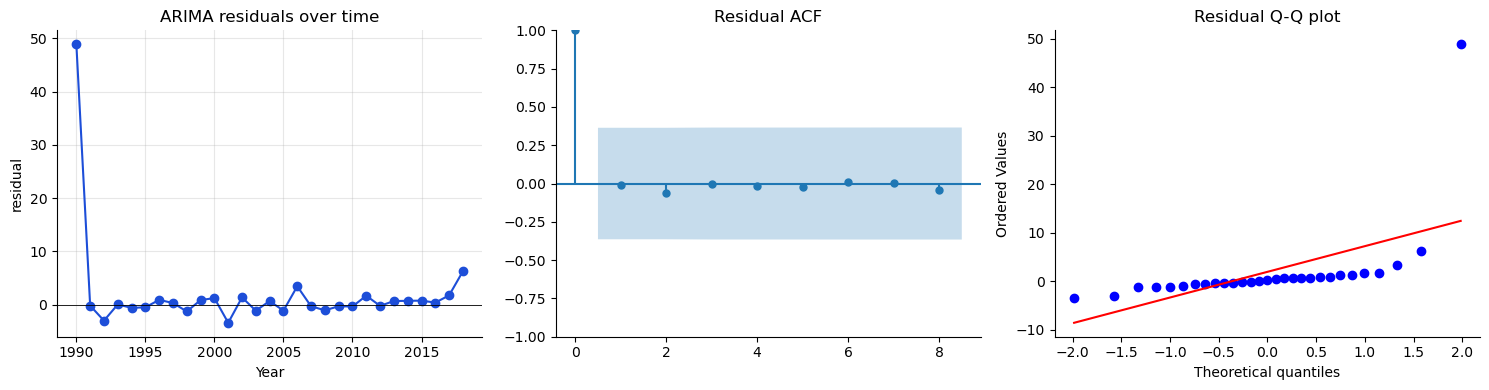

In [10]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats as st

# ARIMA residuals are used as the diagnostic example
resid = best_fit.resid
print(f'Ljung-Box on ARIMA residuals (lags=5):')
lb = acorr_ljungbox(resid, lags=[5], return_df=True)
print(lb.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(tr['year'][:len(resid)], resid, 'o-', color='#1d4ed8')
axes[0].axhline(0, color='black', lw=0.6); axes[0].set_title('ARIMA residuals over time')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('residual'); axes[0].grid(alpha=.3)

plot_acf(resid, lags=min(8, len(resid)//2-1), ax=axes[1])
axes[1].set_title('Residual ACF')

st.probplot(resid, dist='norm', plot=axes[2])
axes[2].set_title('Residual Q-Q plot')
plt.tight_layout(); plt.savefig(DATA/'forecast_baseline_diagnostics.png', dpi=140); plt.show()


## 10. Findings / Выводы

**EN — what the baseline bench establishes (honest, ex-ante).**
- On the 2019–2023 hold-out the two strongest models are **ARIMA(1,1,0) at ≈9.2 % MAPE** and the **ex-ante Ridge at ≈9.7 %** — statistically indistinguishable on five points, both inside Lewis's "excellent" band.
- **The Ridge's apparent ≈4.6 % was a backcast artefact.** Once the model must forecast its own drivers and propagate the demand lag recursively, its error rises to ≈9.7 % and it no longer out-performs ARIMA. The ex-ante number is the defensible headline; the conditional ≈4.6 % figure is retained only as a labelled reference, and the gap between them *is* the backcast advantage.
- **The hold-out is deliberately a structural break.** 2019–2023 contains the post-2018 demand surge (≈+27 % over 2018), so every model under-predicts and most show a **negative $R^2$** against it. This is the finding, not a defect: it quantifies how far the recent regime departs from a simple extrapolation of 1990–2018, and shows that no parsimonious model anticipates a policy-driven break it was never shown.
- **Naïve floors the bench (≈13.9 %); the linear trend is worst (≈30.6 %)** precisely because it ignores the I(1) structure confirmed by ADF in §5.1.

**EN — the organizing logic.** With only ~29 annual training points, the binding constraint is sample size, not model class. Every choice follows from it: parsimonious specifications (one AR term; default Prophet flexibility; CV-shrunk Ridge), cross-validation confined to the training period, strictly ex-ante scoring, and uncertainty reported beside the point error (ADF/KPSS caveats, CV-MAPE spreads, ARIMA prediction intervals). The supervisor's small-sample concern is thereby turned into the design principle of the whole exercise — complexity is added in NB07 only where the data can support it, and always with honest intervals.

**RU — что устанавливает базовый бенчмарк (честно, ex-ante).**
- На отложенной выборке 2019–2023 две сильнейшие модели — **ARIMA(1,1,0), MAPE ≈9,2 %** и **ex-ante Ridge ≈9,7 %** — статистически неразличимы на пяти точках; обе в зоне «отлично» по Lewis.
- **Прежние ≈4,6 % Ridge — артефакт бэккаста.** Когда модель вынуждена прогнозировать собственные драйверы и рекурсивно подавать лаг спроса, ошибка растёт до ≈9,7 %, и преимущество над ARIMA исчезает. Честным заголовком является число ex-ante; условные ≈4,6 % сохранены лишь как помеченный ориентир, а разрыв между ними и есть «преимущество бэккаста».
- **Отложенная выборка намеренно содержит структурный сдвиг.** 2019–2023 включает скачок спроса после 2018 г. (≈+27 % к 2018 г.), поэтому модели недопрогнозируют, а $R^2$ часто отрицателен. Это результат, а не дефект: он показывает, насколько новый режим отклоняется от простой экстраполяции 1990–2018 гг.
- **Наивная модель задаёт нижнюю планку (≈13,9 %); линейный тренд — худший (≈30,6 %)**, так как игнорирует I(1)-структуру, подтверждённую ADF в §5.1.

**RU — организующая логика.** При ~29 годовых наблюдениях ограничением является объём выборки, а не класс модели. Отсюда все решения: экономные спецификации, кросс-валидация только на обучающем периоде, строго ex-ante оценка и неопределённость рядом с точечной ошибкой (оговорки ADF/KPSS, разброс CV-MAPE, прогнозные интервалы ARIMA). Тревога научного руководителя о малой выборке превращается в принцип всей работы; усложнение появляется в NB07 лишь там, где данные это позволяют, и всегда с честными интервалами.

**Next steps / Следующие шаги.** NB07 (`07_forecasting_advanced.ipynb`) extends this with **Bayesian Ridge** (full predictive intervals, self-regularising — no $\alpha$ to hand-tune), a **pooled Central-Asia panel** with country fixed effects (more cross-sectional information for the same short time span), and **gradient-boosted trees with SHAP** — each addressing the small-sample limitation directly.